## $1.$ ***Importing Libraries & Data***

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns',None) # to display all colomns

In [ ]:
train_data = pd.read_csv('train.csv')

## $2.$ ***Exploring Data***

*Preparing data to be processed*

In [ ]:
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train_data.shape

(1460, 81)

In [ ]:
# Turkish paths to extract names of numerical and categorical columns
# Assuming 'Id' is not a feature and should be excluded from numerical columns, cause it is an identifier
# Used set() to exclude 'Id' from the list of numerical columns
numerical_colomns = list(set(train_data.select_dtypes(include='number').columns) - set(['Id']))
categorical_colomns = list(set(train_data.columns) - set(numerical_colomns) - set(['Id']))

In [ ]:
# This tip depends on that describe() method returns numerical columns by default
num_cols = list(set(train_data.describe().columns) - set([ 'Id'])) # to display numerical columns - tip: without creating list variable
cat_cols = list(set(train_data.columns) - set(num_cols)- set(['Id']))

In [ ]:
num_cols.__contains__('Id')

False

array([[<Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'GarageArea'}>,
        <Axes: title={'center': 'FullBath'}>],
       [<Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': 'PoolArea'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'LowQualFinSF'}>],
       [<Axes: title={'center': 'KitchenAbvGr'}>,
        <Axes: title={'center': 'BedroomAbvGr'}>,
        <Axes: title={'center': 'Fireplaces'}>,
        <Axes: title={'center': 'OpenPorchSF'}>],
       [<Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': '3SsnPorch'}>,
        <Axes: title={'center': 'MiscVal'}>],
       [<Axes: title={'center': 'TotRmsAbvGrd'}>,
        <Axes: title={'center': 'WoodDeckSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>, <Axes: >]], dtype=object)

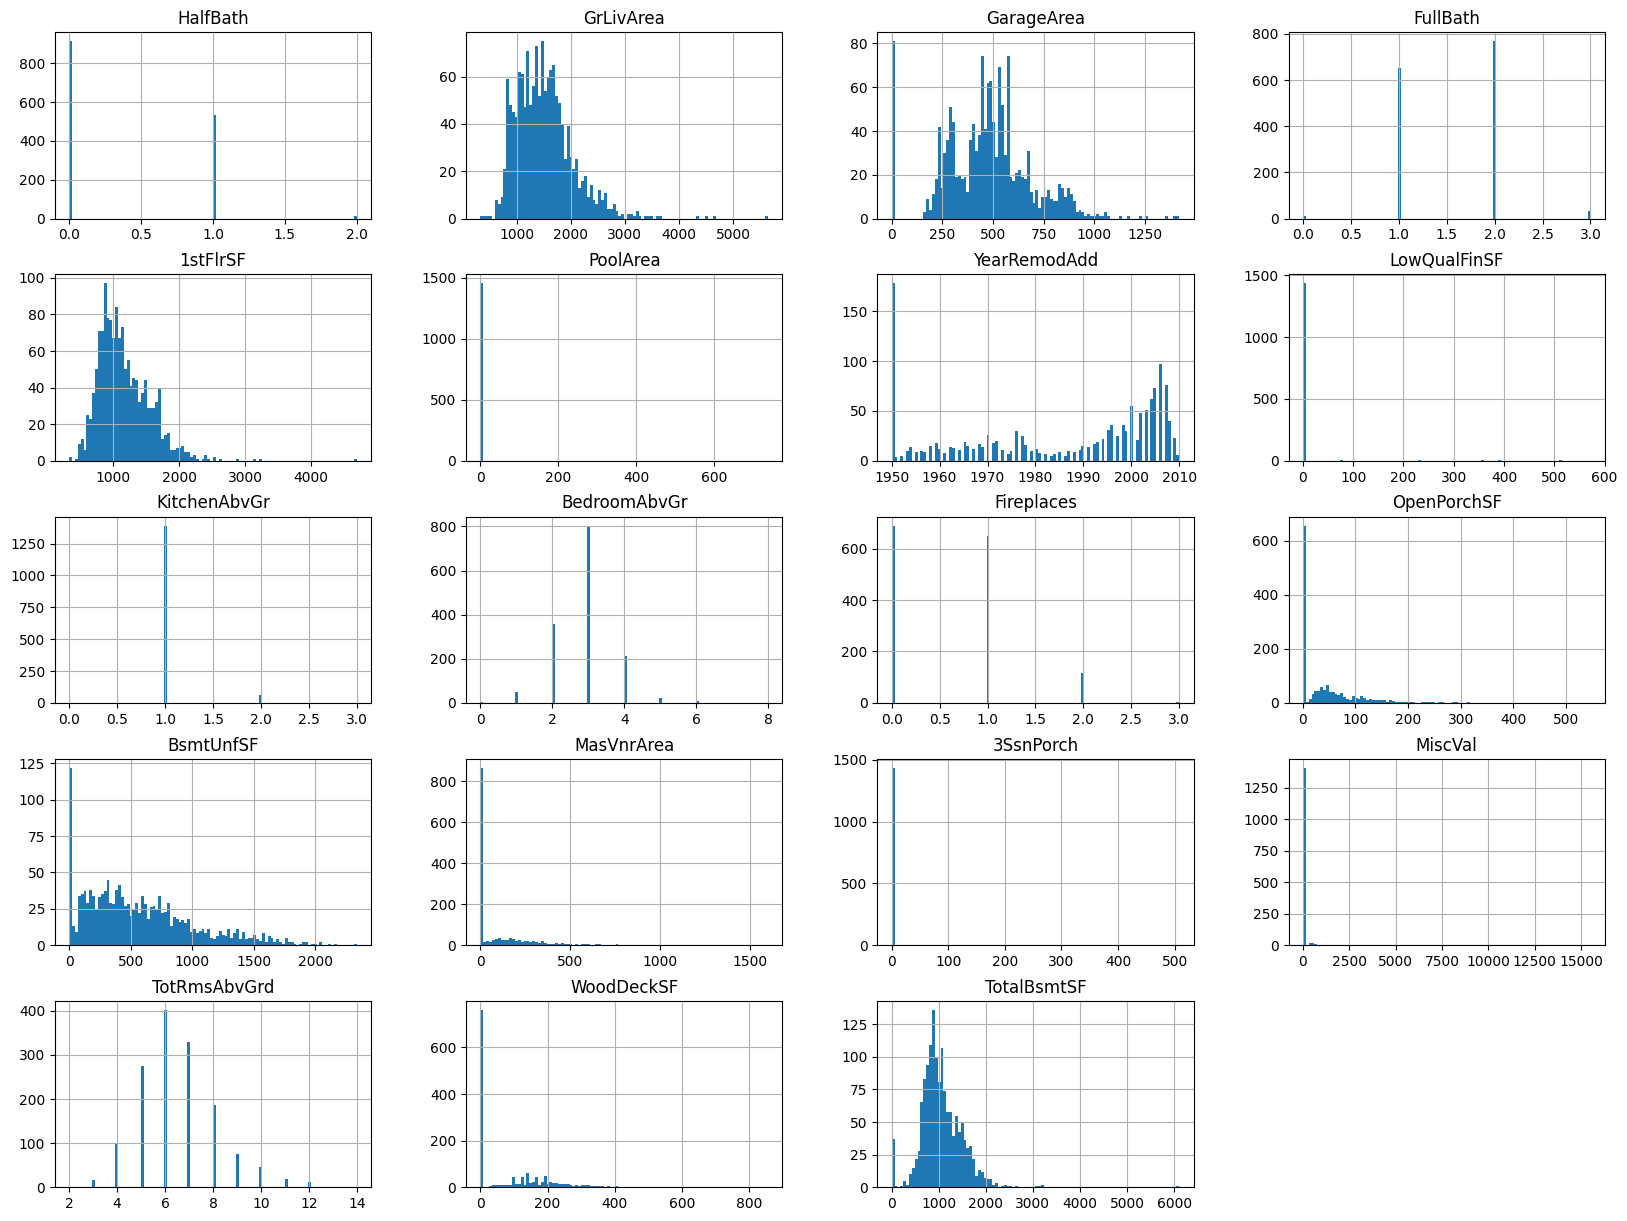

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
train_data [num_cols[:19]].hist(bins=100,figsize=(20,15))

array([[<Axes: title={'center': 'EnclosedPorch'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'YrSold'}>],
       [<Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'YearBuilt'}>],
       [<Axes: title={'center': 'SalePrice'}>,
        <Axes: title={'center': 'MoSold'}>,
        <Axes: title={'center': 'GarageCars'}>,
        <Axes: title={'center': 'ScreenPorch'}>],
       [<Axes: title={'center': 'GarageYrBlt'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>],
       [<Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': '2ndFlrSF'}>, <Axes: >, <Axes: >]],
      dtype=object)

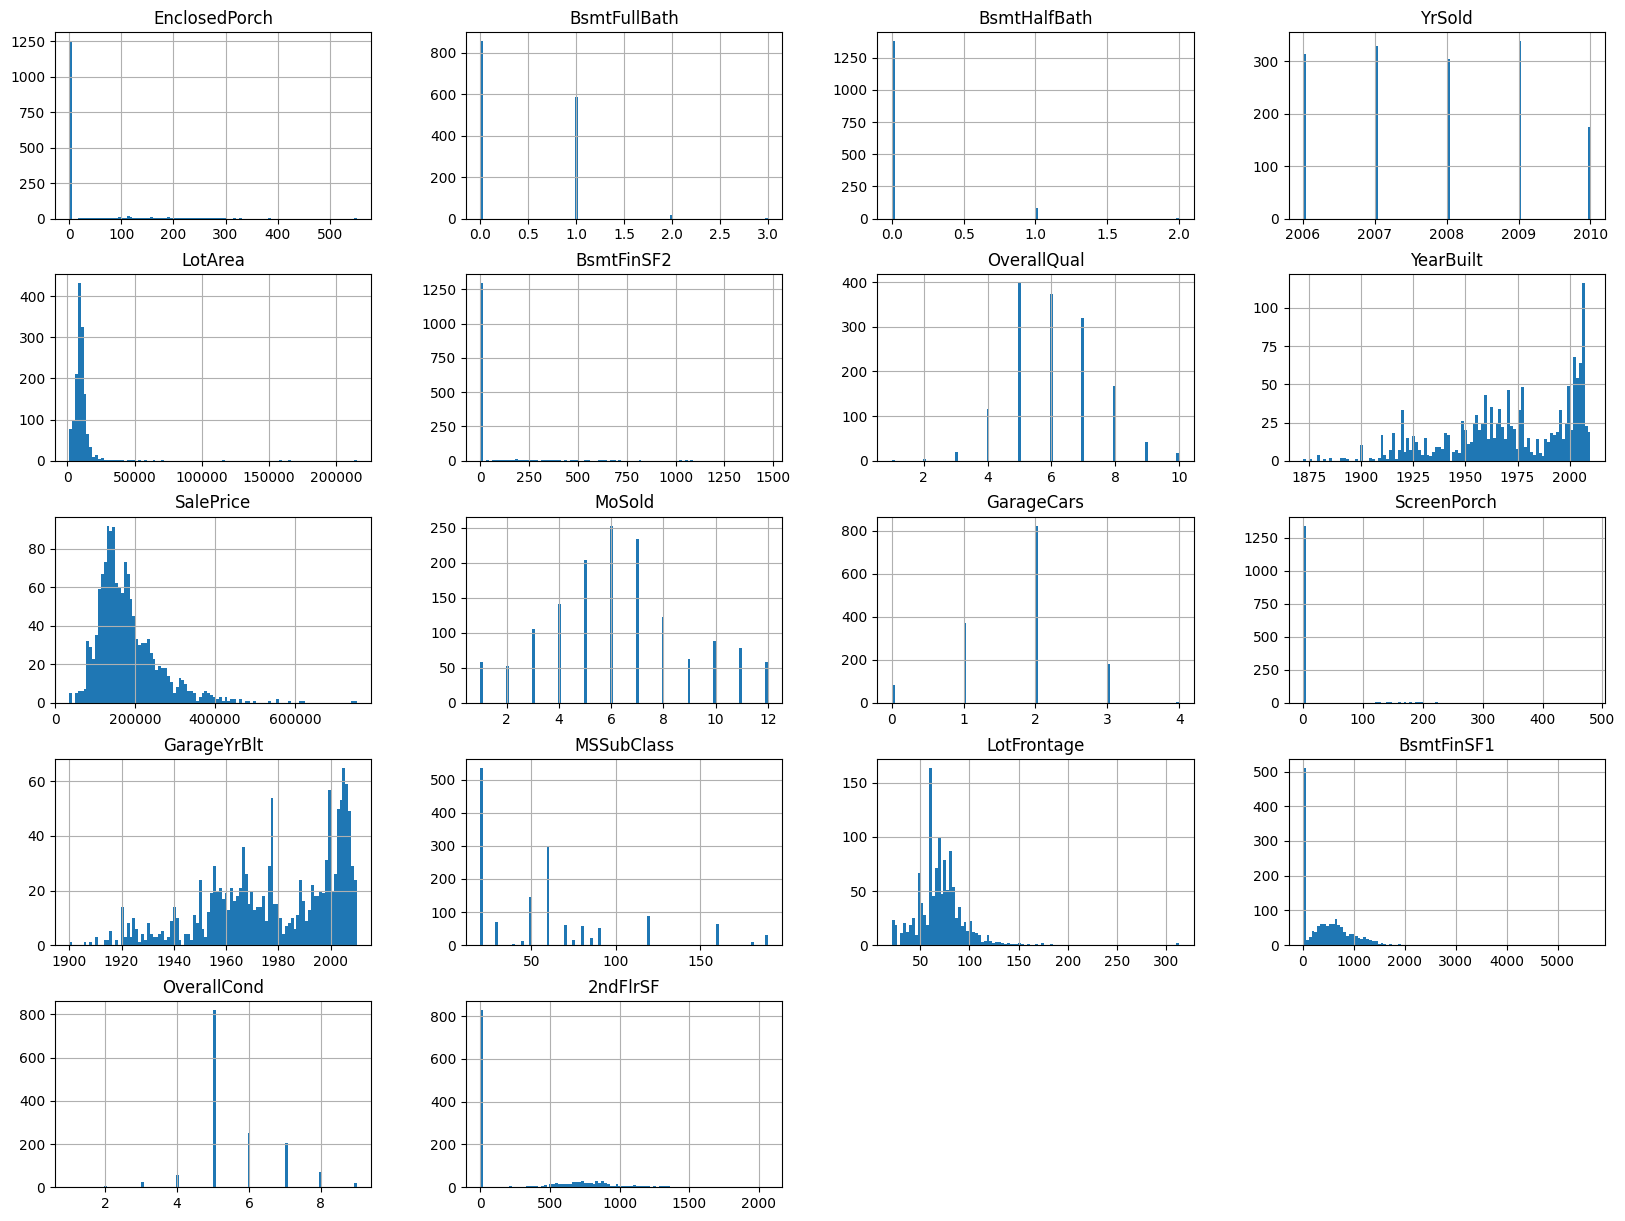

In [ ]:
train_data [num_cols[19:]].hist(bins=100,figsize=(20,15))

In [ ]:
corr_matrix = train_data[num_cols].corr()
# train_data[num_cols].corr().style.background_gradient(cmap='coolwarm')

<Axes: >

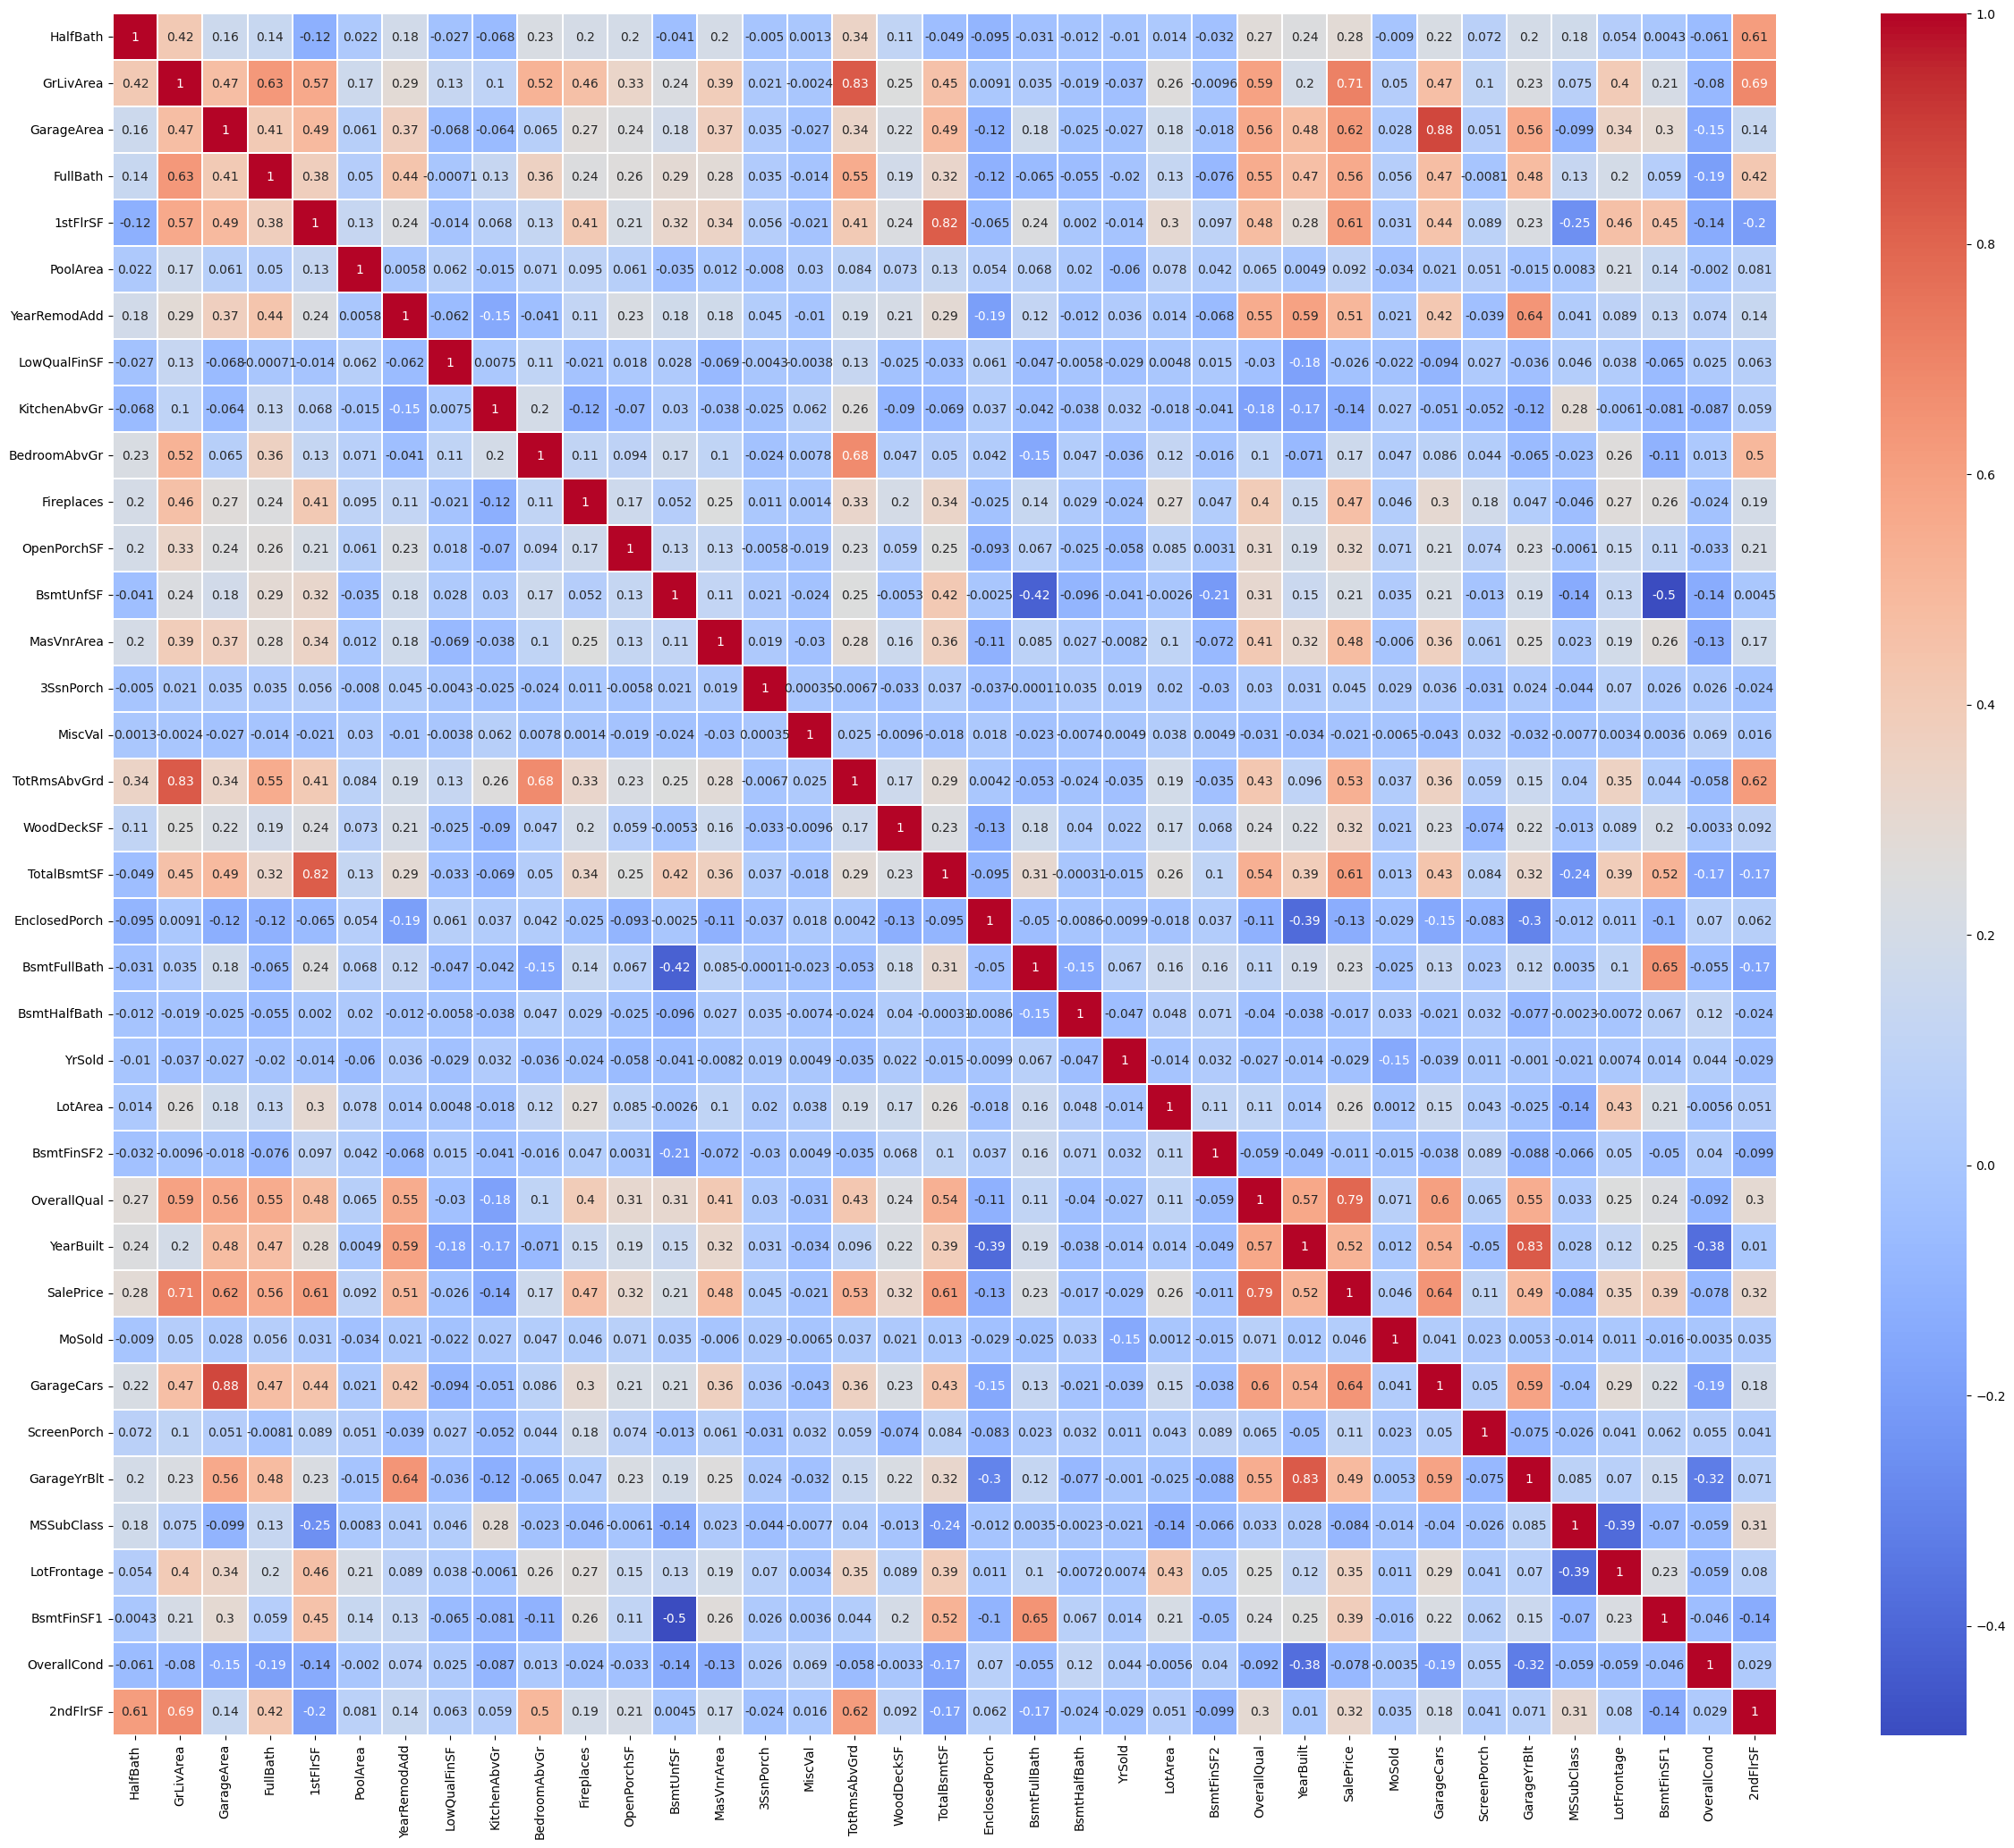

In [ ]:
import seaborn as sns
plt.subplots(figsize=(30,25))
sns.heatmap(
    corr_matrix,
   # xticklabels=corr_matrix.columns.values,  # un necessary, as it is the default, because we are using a data frame
   # yticklabels=corr_matrix.columns.values,
    linewidths=0.1,
    annot=True,
    cmap='coolwarm'
)

## $3.$ ***Handling null values***

In [ ]:
nulls_df =  train_data.isna().sum().reset_index().rename(columns={0:"Nulls_Count"}) # calculate nulls count for each column, then rename the column to 'Nulls_Count'
nulls_df[nulls_df['Nulls_Count']>0].sort_values(by=['Nulls_Count'],ascending=False) # sorting the columns that have nulls in descending order

,index,Nulls_Count
72,PoolQC,1453
74,MiscFeature,1406
6,Alley,1369
73,Fence,1179
25,MasVnrType,872
57,FireplaceQu,690
3,LotFrontage,259
58,GarageType,81
59,GarageYrBlt,81
60,GarageFinish,81


In [ ]:
features_to_be_dropped =['PoolQC','MiscFeature','Alley','Fence','MasVnrType','FireplaceQu'] # Drop columns with high percentage of nulls(>60%)
features_to_be_filled = ['LotFrontage'] # Fill columns with low percentage of nulls (<60%) with mean or mode or any other Imputing technique
dropping_na_rows      = ['GarageType','GarageYrBlt','GarageFinish','GarageQual','GarageCond','BsmtExposure','BsmtFinType2','BsmtQual','BsmtCond','BsmtFinType1','MasVnrArea','Electrical'] # neglegable columns with low percentage of nulls (<5%) and can be dropped


In [ ]:
# Fill the columns using KNNImputer technique
from sklearn.impute import KNNImputer
train_data['LotFrontage'] = KNNImputer(n_neighbors=3).fit_transform(train_data[['LotFrontage']])

In [ ]:
train_data.drop(columns=features_to_be_dropped,inplace=True)
# train_data['LotFrontage'].fillna(train_data['LotFrontage'].mean(),inplace=True)
train_data.dropna(subset=dropping_na_rows,inplace=True)

In [ ]:
train_data.isna().sum().reset_index().rename(columns={0:"Nulls_Count"})

,index,Nulls_Count
0,Id,0
1,MSSubClass,0
2,MSZoning,0
3,LotFrontage,0
4,LotArea,0
...,...,...
70,MoSold,0
71,YrSold,0
72,SaleType,0
73,SaleCondition,0


## $4.$ ***Dropping redundant data***

In [ ]:
num_cols = list(set(train_data.describe().columns) - set(['Id']))
cat_cols = list(set(train_data.columns) - set(num_cols)- set(['Id']))


![image.png](attachment:image.png)

In [ ]:
# redundant_rows = []
# for i in num_cols:
#     for j in range(train_data[i].unique().shape[0]):
#         if ((train_data.groupby([i])['Id'].count().iloc[j] / train_data[i].count())*100) > 80:
#             # print(((train_data.groupby([i])['SaleCondition'].count().iloc[j] / train_data[i].count())*100))
#             redundant_rows.append(i)
# for i in cat_cols:
#     for j in range(train_data[i].unique().shape[0]):
#         if ((train_data.groupby([i])['Id'].count().iloc[j] / train_data[i].count())*100) > 80:
#             # print(((train_data.groupby([i])['SaleCondition'].count().iloc[j] / train_data[i].count())*100))
#             redundant_rows.append(i)
# len(redundant_rows)

In [ ]:
# # Generalised approach
# def find_redundant_cols(df,cols):
#     redundant_rows = []
#     for i in cols:
#         for j in range(df[i].unique().shape[0]):
#             if ((df.groupby([i])[df.columns[0]].count().iloc[j] / df[i].count())*100) > 80:
#                 redundant_rows.append(i)
#     return redundant_rows

In [ ]:
# Generalised approach
def find_redundant_cols(df, threshold=0.8):
    redundant_cols = []
    for col in df.columns:
        if (df[col].value_counts().iloc[0]/len(df[col])) > threshold:
            redundant_cols.append(col)
    return redundant_cols

In [ ]:
# Dropping redundant values
cols_with_redundant_values = find_redundant_cols(train_data)

In [ ]:
train_data.drop(columns= cols_with_redundant_values , inplace=True)

## $5.$ ***Correlations***

### If we have 2 correlated features (corr > 0.7), we drop one of them( the one which is less corredlated to the response value "Target feature" )

In [ ]:
num_cols = list(set(train_data.select_dtypes(include='number').columns) - set(['Id']))
cat_cols = list(set(train_data.columns) - set(num_cols)- set(['Id']))

In [ ]:
corr_mat = train_data[num_cols].corr()

In [ ]:
# highly_correlated = set()
# for col in num_cols:
#     for ro in num_cols:
#         if ro == col or ro == 'SalePrice' or ro == 'SalePrice' :
#             continue
#         if corr_mat[col][ro] > 0.7:
#             if corr_mat[col]['SalePrice'] > corr_mat[ro]['SalePrice']:
#                 highly_correlated.add(col)
#             else:
#                 highly_correlated.add(ro)
# highly_correlated.remove('SalePrice')

In [ ]:
# highly_correlated

In [ ]:
def highly_correlated_columns(corr_mat:pd.DataFrame, Target_Column: str,threshold=0.7 ):
    highly_correlated = set()
    for col in corr_mat.columns:
        for ro in corr_mat.columns:
            if ro == col or ro == Target_Column or col == Target_Column :
                continue
            elif abs(corr_mat[col][ro]) > threshold:
                if corr_mat[col][Target_Column] > corr_mat[ro][Target_Column]:
                    highly_correlated.add(ro)
                else:
                    highly_correlated.add(col)
    return highly_correlated

In [ ]:
highly_correlated_columns(corr_mat,'SalePrice')

{'GarageArea', 'GarageYrBlt', 'TotRmsAbvGrd', 'TotalBsmtSF'}

## $6.$ ***Outliers***
**Using The $IQR$(Inter Quartile Range) method:**

&emsp;&emsp;***$IQR$***: *The $IQR$ gives us a sense of the data’s spread around the median, excluding possible outliers.*<br>
    &emsp;&emsp;&emsp;&emsp;&emsp;--> ***$IQR$*** = $Q3$ -$ Q1$<br>
    &emsp;&emsp;&emsp;&emsp;&emsp;--> ***$Q1$*** = the median of the set of numbers below the median. <br>
    &emsp;&emsp;&emsp;&emsp;&emsp;--> ***$Q3$*** = the median of the set of numbers above the median.<br>

*The Upper bound* = $IQR$ + 1.5 * $Q3$<br>
*The Lower bound* = $IQR$ - 1.5 * $Q1$

In [ ]:
def Clamping_Outliers(df,Target_Columns,threshold=1.5):
    for col in  Target_Columns:
        Q1 = np.percentile(df[col],25)
        Q3 = np.percentile(df[col],75)

        IQR = Q3 - Q1

        Upper = Q3 + threshold * IQR
        Lower = Q1 - threshold * IQR

        df.loc[df[col] < Lower,col] = Lower
        df.loc[df[col] > Upper,col] = Upper
    return df

In [ ]:
train_data = Clamping_Outliers(train_data,num_cols)

C:\Users\Turkish\AppData\Local\Temp\ipykernel_8064\1102398298.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < Lower,col] = Lower
C:\Users\Turkish\AppData\Local\Temp\ipykernel_8064\1102398298.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '212.75' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < Lower,col] = Lower
C:\Users\Turkish\AppData\Local\Temp\ipykernel_8064\1102398298.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] < Lower,col] = Lower
C:\Users\T

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,Foundation,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,MoSold,YrSold,SalePrice
0,1,60,RL,65.0,8450.0,Reg,Inside,CollgCr,2Story,7,5.0,2003.0,2003,Gable,VinylSd,VinylSd,196.0,Gd,PConc,Gd,No,GLQ,706.0,150.0,856.0,Ex,856,854.0,1710.0,1.0,2.0,1.0,3.0,Gd,8,0.0,Attchd,2003.0,RFn,2.0,548.0,0.00,61,2.0,2008,208500
1,2,20,RL,80.0,9600.0,Reg,FR2,Veenker,1Story,6,7.5,1976.0,1976,Gable,MetalSd,MetalSd,0.0,TA,CBlock,Gd,Gd,ALQ,978.0,284.0,1262.0,Ex,1262,0.0,1262.0,0.0,2.0,0.0,3.0,TA,6,1.0,Attchd,1976.0,RFn,2.0,460.0,298.00,0,5.0,2007,181500
2,3,60,RL,68.0,11250.0,IR1,Inside,CollgCr,2Story,7,5.0,2001.0,2002,Gable,VinylSd,VinylSd,162.0,Gd,PConc,Gd,Mn,GLQ,486.0,434.0,920.0,Ex,920,866.0,1786.0,1.0,2.0,1.0,3.0,Gd,6,1.0,Attchd,2001.0,RFn,2.0,608.0,0.00,42,9.0,2008,223500
3,4,70,RL,60.0,9550.0,IR1,Corner,Crawfor,2Story,7,5.0,1915.0,1970,Gable,Wd Sdng,Wd Shng,0.0,TA,BrkTil,TA,No,ALQ,216.0,540.0,756.0,Gd,961,756.0,1717.0,1.0,1.0,0.0,3.0,Gd,7,1.0,Detchd,1998.0,Unf,3.0,642.0,0.00,35,2.0,2006,140000
4,5,60,RL,84.0,14260.0,IR1,FR2,NoRidge,2Story,8,5.0,2000.0,2000,Gable,VinylSd,VinylSd,350.0,Gd,PConc,Gd,Av,GLQ,655.0,490.0,1145.0,Ex,1145,1053.0,2198.0,1.0,2.0,1.0,4.0,Gd,9,1.0,Attchd,2000.0,RFn,3.0,836.0,192.00,84,12.0,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917.0,Reg,Inside,Gilbert,2Story,6,5.0,1999.0,2000,Gable,VinylSd,VinylSd,0.0,TA,PConc,Gd,No,Unf,0.0,953.0,953.0,Ex,953,694.0,1647.0,0.0,2.0,1.0,3.0,TA,7,1.0,Attchd,1999.0,RFn,2.0,460.0,0.00,40,8.0,2007,175000
1456,1457,20,RL,85.0,13175.0,Reg,Inside,NWAmes,1Story,6,6.0,1978.0,1988,Gable,Plywood,Plywood,119.0,TA,CBlock,Gd,No,ALQ,790.0,589.0,1542.0,TA,2073,0.0,2073.0,1.0,2.0,0.0,3.0,TA,7,2.0,Attchd,1978.0,Unf,2.0,500.0,349.00,0,2.0,2010,210000
1457,1458,70,RL,66.0,9042.0,Reg,Inside,Crawfor,2Story,7,7.5,1941.0,2006,Gable,CemntBd,CmentBd,0.0,Ex,Stone,TA,No,GLQ,275.0,877.0,1152.0,Ex,1188,1152.0,2340.0,0.0,2.0,0.0,4.0,Gd,9,2.0,Attchd,1941.0,RFn,1.0,252.0,0.00,60,5.0,2010,266500
1458,1459,20,RL,68.0,9717.0,Reg,Inside,NAmes,1Story,5,6.0,1950.0,1996,Hip,MetalSd,MetalSd,0.0,TA,CBlock,TA,Mn,GLQ,49.0,0.0,1078.0,Gd,1078,0.0,1078.0,1.0,1.0,0.0,2.0,Gd,5,0.0,Attchd,1950.0,Unf,1.0,240.0,366.00,0,4.0,2010,142125


## $7.$ ***Skewness***<br>
***The danger of Skewness:***  the fanning-out of the regression line resulting in high variance value (sigma square) in different data points.<br>

### *Types of Skewness*:
***1-Left-Skewed-Data(Negative-Skewed):*** *"The Median" and "The Mean" are shifted to the lift of "The Mode"; according to the Highly negative or the very small values in the data.*<br>
***2-Right-Skewed-Data(Positive-Skewed):*** *"The Median" and "The Mean" are shifted to the right of "The Mode"; according to the very High values in the data.*<br>

![image.png](attachment:image.png)

***$Z-Score$:*** Calculates how many standard deviations (***σ***) from the mean of your data.<br>
*$Z-Score$ Formula:*
$$
Z = \frac{x - \mu}{\sigma}
$$
**$x$** --> The data point <br>
***$μ$*** --> The mean of your data<br>
***$σ$*** --> The standard Deviation<br>
Skewness Coffecient is the average value of $Z^3$<br>
$$\text{Skewness} = \frac{\sum_{i=1}^{N} (X_i - \bar{X})^{3}}{(N-1)\sigma^{3}}$$

***--> After detecting skewed-data you should transform and normalize data here we used "$Log$-$Transformation$" Technique***
**$$Y = \log\bigl(1 + |x|\bigr)$$**




In [ ]:
# first simple skewness calculator
def Skewness_calculator(df: pd.DataFrame,Target_columns: list):
    skewness_dictionary= dict()
    for i in Target_columns:
        col_mean = df[i].mean()
        lower = (df[i].shape[0] - 1) * (df[i].std()**3)
        upper = 0
        for j in df[i]:
            upper += (j - col_mean)** 3
        skewness_dictionary[i] = (upper / lower)
    return skewness_dictionary

In [ ]:
# second simpler skewness calculator
def Skewness_calculator(df: pd.DataFrame,Target_columns: list):
    skewness_dictionary= dict()
    for i in Target_columns:
        col_mean = df[i].mean()
        skewness_dictionary[i] = ((((df[i] - col_mean)**3).sum()) / ((df[i].shape[0] - 1) * (df[i].std()**3)) )
    return skewness_dictionary

In [ ]:
def Skewness_calculator(df: pd.DataFrame,Target_columns: list):
    means = df[Target_columns].mean(axis=0)
    stds = df[Target_columns].std(axis=0)
    skewness_dictionary = (((df[Target_columns] - means)**3).sum(axis=0)) / ((df.shape[0] - 1) * stds**3)
    return skewness_dictionary

In [ ]:
# there's a problem with negative skewed data
def Skewness_transformation(df: pd.DataFrame,Target_columns: list):
    skewness_val = Skewness_calculator(df , Target_columns)
    for i in skewness_val.keys():
        if abs(skewness_val[i]) > 1 :
            df[i] = df[i].apply(lambda x : np.log(1+abs(x))) # df[i] = np.sign(df[i]) * np.log1p(df[i].abs()) <-- Solution
            print(f"column {i} is transformed")
    return df

In [ ]:
train_data = Skewness_transformation(train_data,num_cols)

column OpenPorchSF is transformed
column MasVnrArea is transformed
column MSSubClass is transformed
column WoodDeckSF is transformed


In [ ]:
Skewness_calculator(train_data , num_cols)

HalfBath        0.553185
GrLivArea       0.602070
GarageArea      0.439807
BsmtFullBath    0.459178
YrSold          0.109181
FullBath       -0.014154
LotArea         0.192272
1stFlrSF        0.660330
YearRemodAdd   -0.562503
OverallQual     0.314747
YearBuilt      -0.655407
SalePrice       0.857376
BedroomAbvGr   -0.292876
Fireplaces      0.500026
MoSold          0.204950
OpenPorchSF    -0.131333
BsmtUnfSF       0.797075
GarageCars      0.134284
2ndFlrSF        0.756801
MasVnrArea      0.373908
GarageYrBlt    -0.667238
MSSubClass      0.141977
LotFrontage     0.065127
BsmtFinSF1      0.695221
OverallCond     0.672074
TotRmsAbvGrd    0.409619
WoodDeckSF      0.065575
TotalBsmtSF     0.628708
dtype: float64

## $7.1.$ ***Feature Scaling***<br>
### **The importance of feature scaling:**<br>
&emsp;&emsp;&emsp; $1.$ Fixing The Issues That can result from different value ranges or units in datasets; as these results could cause bias in the models like: <br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;Gradiant Descent based algorithms, $KNN$, and $SVM$; any distance calculations. <br>
&emsp;&emsp;&emsp; $2.$ Creating interaction terms; when one feature created from two variables that are not centered on 0, some amout of collinearity will be induced.<br><br>

### **Methods of feature Scaling:**<br>
 &emsp;&emsp;&emsp;$1.$ ***Normalization*** ($Min$-$Max$ Scaling): Ranging Values from 0:1.<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;***When to use?***  --> when features are in different scales, no matter the distribution.<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; **-->** *Higly affected by $outliers$*<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ***$Formula$***: $$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$<br>
 &emsp;&emsp;&emsp;$2.$ ***Standardization*** ($Z$-$score$ Normalization): Getting the $Z$-$Score$ for each value in the column.<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;***When to use?***  --> when dealing with normally distributed values; other wise it's meaningless.<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; **-->** *Less affected by $outliers$* from Normalization.<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ***$Formula$***: $$z = \frac{x - \mu}{\sigma}$$<br>
&emsp;&emsp;&emsp;$3.$ ***Robust Scaling***: Scaling values using the median and the Interquartile Range ($IQR$).<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;***When to use?***  --> when dataset contains many $outliers$ that can heavily affect Min–Max or Z–Score scaling.<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; **-->** *Highly $resistant$ to outliers.*<br>
 &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; ***$Formula$***:  $$x' = \frac{x - \text{Median}(x)}{IQR}$$ where $IQR = Q_3 - Q_1$.<br>

In [ ]:
# Normalization
def Normalization_Min_Max(df: pd.DataFrame, Target_columns: list):
    for col in Target_columns:
        df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    return df

In [ ]:
# Standardization
def Standardization_Z_Score(df: pd.DataFrame, Target_Columns: list):
    for col in Target_Columns:
        df[col] = ((df[col] - df[col].mean()) / (df[col].std()))
    return df

In [ ]:
# Robust Scaling
def Robust_Scaling(df: pd.DataFrame, Target_Columns):
    for col in Target_Columns:
        Q1 = np.percentile(df[col],25)
        Q3 = np.percentile(df[col],75)

        IQR = Q3 - Q1

        df[col] = ((df[col] - df[col].median()) / IQR)
    return df

## $7.2.$ $Q-Q$ $Plot$<br>
#### What's ***Q-Q Plot*** (Quantile-Quantile Plot)?<br>
&emsp;&emsp;&emsp;&emsp; $-$> Plots of two ***quantiles*** against each other.<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;$--$> A ***Quantille*** is a fraction where certain values fall below that quantile. <br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;$---$> **Ex:->** ***Median:*** is a quantile where 50% of the data fall below that Point, and 50% lie above it.<br>

on the $x$-axis $-$> plot the $z-Score$ values of the Perfect Normal Distribution for your data.<br>
on the $y$-axis $-$> plot the values of Your Data.<br

#### why ***Q-Q Plot*** ?<br>
&emsp;&emsp;&emsp;&emsp; $-$> To determine what technique you're gonna use in scaling data (Normalization,Standardization,...)

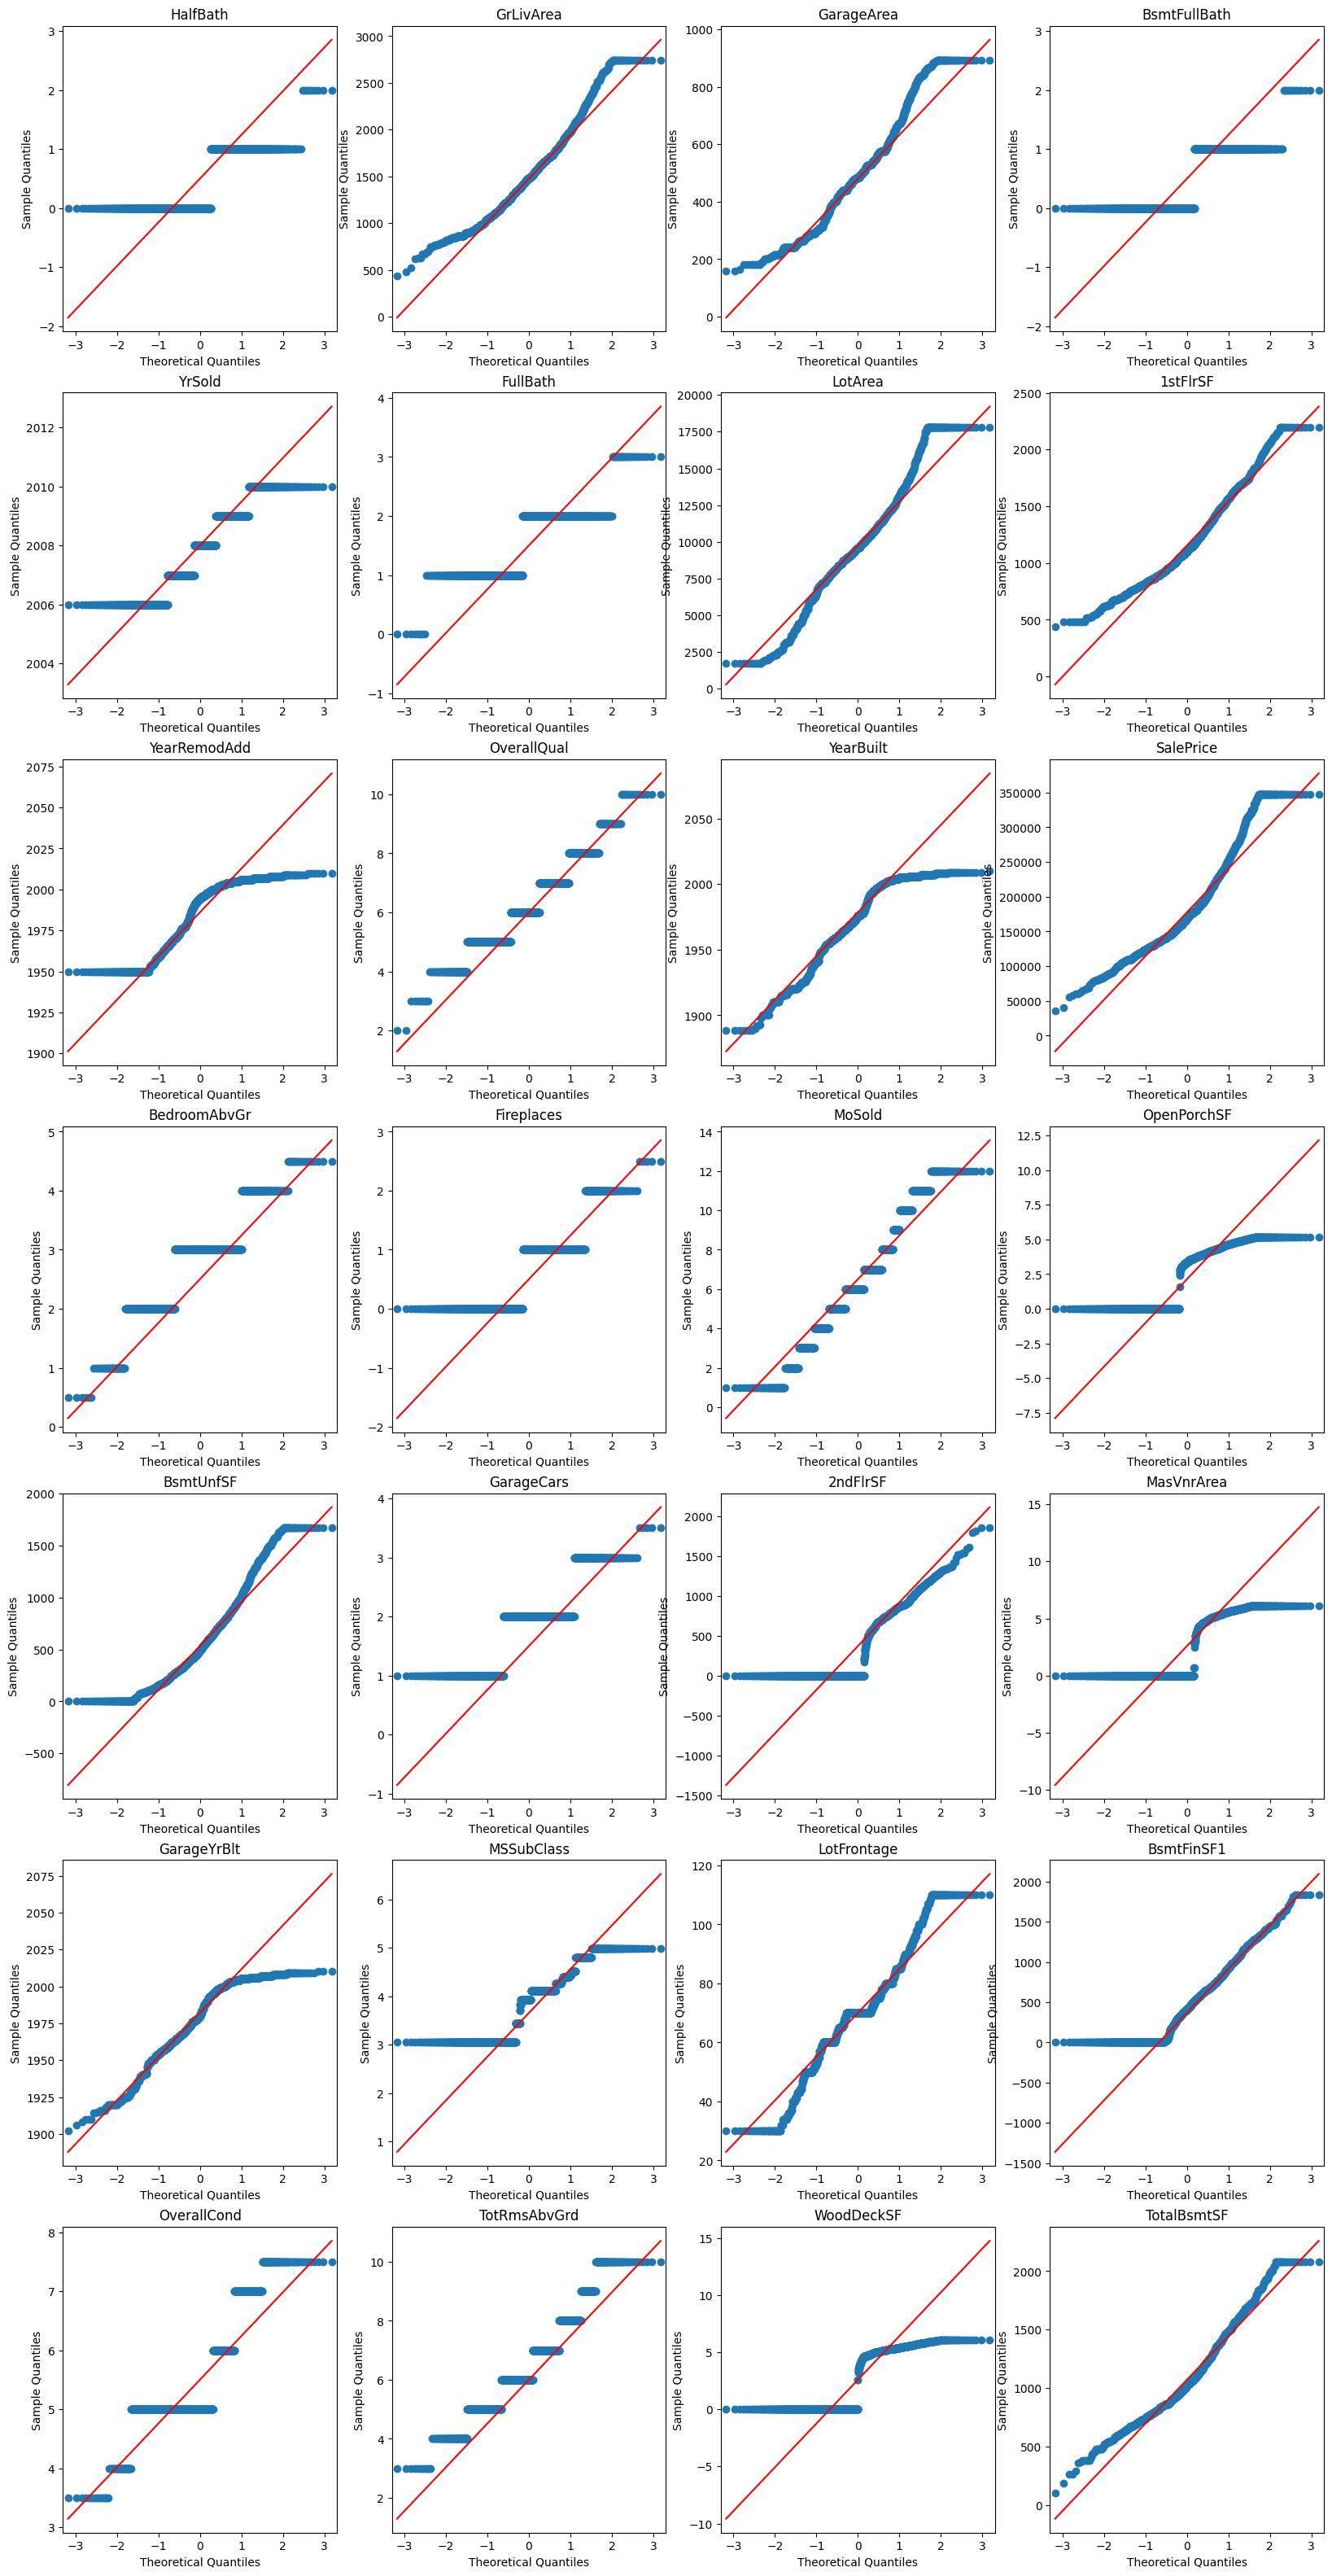

In [ ]:
# we won't use this method because it's not automated, and depends on graphs.
import statsmodels.api as sm
ncols = 4
nrows=7
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, figsize=(20, 40))
i=0
j=0
for col in num_cols:
    sm.qqplot(train_data[col],fit = False, line='q', ax = axes[i, j])

    axes[i, j].set_title(col)


    if(j<ncols-1):
        j+=1
    else:
        i+=1
        j=0
plt.show()

## $7.3.$ ***Shapiro-Wilk***<br>

#### What's ***Shapiro-Wilk Test?***<br>
- A Statistical Test To check the normality of data (*similar to Q-Q plot; but Q-Q plot is a graphical method*).<br>

#### ***Why Shapiro-Wilk Test?***<br>
- Unlike the graphical solution where you visually judge normality, with *Shapiro-Wilk* test you take action based on numerical results.<br>
- The test outputs two values:  
  - **$W$** → The test statistic (how close data is to normal).  
  - **$p$** → The p-value (used to decide normality).  

#### ***Formula:***  
$$W = \frac{\left( \sum_{i=1}^{n} a_i x_{(i)} \right)^2}{\sum_{i=1}^{n} \left(x_i - \bar{x}\right)^2}$$


- $x_{(i)}$ → the $i^{th}$ order statistic (sample values sorted in ascending order).  
- $\bar{x}$ → The sample mean.  

> If data lines up with the expected normal distribution, $W \approx 1$.  
> If $W < 1$, data deviates from normality.  

---

#### ***Hypothesis Testing Setup:***  
- $H_0$: Data is normally distributed.  
- $H_1$: Data is not normally distributed.  
- $\alpha$: The significance level (commonly 0.05).  

---

#### ***Why use $p$ instead of $W$?***  
- $W$ only measures *closeness* to normality (always between 0 and 1).  
- But the **decision rule** comes from comparing the **p-value** with $\alpha$:  
  - If $p > \alpha$ → Fail to reject $H_0$ → Data looks normal.  
  - If $p \leq \alpha$ → Reject $H_0$ → Data is not normal.  

That’s why we rely on **$p$**, not just the raw $W$ value, to make statistical decisions.  


In [ ]:
from scipy.stats import shapiro
standard_scale_features = ['Fireplaces']
min_max_scale_features = []
for col in num_cols:
    stat,p = shapiro(train_data[col])
    print(f"The {col} statistcs are: \n 1- W(statistic) = {stat : .3f}   ,   P = {p:.10f}")

    alpha = 0.05
    if p > alpha:
        standard_scale_features.append(col)
    else:
        min_max_scale_features.append(col)

The HalfBath statistcs are: 
 1- W(statistic) =  0.643   ,   P = 0.0000000000
The GrLivArea statistcs are: 
 1- W(statistic) =  0.966   ,   P = 0.0000000000
The GarageArea statistcs are: 
 1- W(statistic) =  0.965   ,   P = 0.0000000000
The BsmtFullBath statistcs are: 
 1- W(statistic) =  0.660   ,   P = 0.0000000000
The YrSold statistcs are: 
 1- W(statistic) =  0.896   ,   P = 0.0000000000
The FullBath statistcs are: 
 1- W(statistic) =  0.716   ,   P = 0.0000000000
The LotArea statistcs are: 
 1- W(statistic) =  0.978   ,   P = 0.0000000000
The 1stFlrSF statistcs are: 
 1- W(statistic) =  0.962   ,   P = 0.0000000000
The YearRemodAdd statistcs are: 
 1- W(statistic) =  0.862   ,   P = 0.0000000000
The OverallQual statistcs are: 
 1- W(statistic) =  0.941   ,   P = 0.0000000000
The YearBuilt statistcs are: 
 1- W(statistic) =  0.918   ,   P = 0.0000000000
The SalePrice statistcs are: 
 1- W(statistic) =  0.930   ,   P = 0.0000000000
The BedroomAbvGr statistcs are: 
 1- W(statistic) =

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [ ]:
# official approach
min_max_scaler = MinMaxScaler()
min_max_scaler_model = min_max_scaler.fit(train_data[min_max_scale_features])
min_max_scaled_data = pd.DataFrame(min_max_scaler_model.transform(train_data[min_max_scale_features]), columns = min_max_scale_features)

In [ ]:
# my approach depending on my normalization function.
# choose what makes you feel comfortable
Normalization_Min_Max(train_data,min_max_scale_features)['1stFlrSF'].value_counts()

1stFlrSF
0.242597    21
1.000000    17
0.269932    13
0.259681    12
0.233485    12
            ..
0.698178     1
0.556948     1
0.318907     1
0.956150     1
0.310934     1
Name: count, Length: 711, dtype: int64

In [ ]:
# official approach
std_scaler = StandardScaler()
std_scaler_model = std_scaler.fit(train_data[standard_scale_features])
std_scaled_data =pd.DataFrame( std_scaler_model.transform(train_data[standard_scale_features]), columns = standard_scale_features)

In [ ]:
# my approach depending on my normalization function.
# choose what makes you feel comfortable
Standardization_Z_Score(train_data,standard_scale_features)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,Foundation,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,FullBath,HalfBath,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,MoSold,YrSold,SalePrice
0,1,0.549925,RL,0.4375,0.418941,Reg,Inside,CollgCr,2Story,0.625,0.375,0.942387,0.883333,Gable,VinylSd,VinylSd,0.869285,Gd,PConc,Gd,No,GLQ,0.385266,0.089962,0.380181,Ex,0.238041,0.461310,0.552863,0.5,0.666667,0.5,0.625,Gd,0.714286,-1.011870,Attchd,0.935185,RFn,0.4,0.530598,0.000000,0.798210,0.090909,0.50,0.554757
1,2,0.000000,RL,0.6250,0.490516,Reg,FR2,Veenker,1Story,0.500,1.000,0.720165,0.433333,Gable,MetalSd,MetalSd,0.000000,TA,CBlock,Gd,Gd,ALQ,0.533697,0.170328,0.585712,Ex,0.469248,0.000000,0.358144,0.0,0.666667,0.0,0.625,TA,0.428571,0.552407,Attchd,0.685185,RFn,0.4,0.410256,0.937495,0.000000,0.363636,0.25,0.468271
2,3,0.549925,RL,0.4750,0.593211,IR1,Inside,CollgCr,2Story,0.625,0.375,0.925926,0.866667,Gable,VinylSd,VinylSd,0.838113,Gd,PConc,Gd,Mn,GLQ,0.265211,0.260289,0.412580,Ex,0.274487,0.467792,0.585896,0.5,0.666667,0.5,0.625,Gd,0.428571,0.552407,Attchd,0.916667,RFn,0.4,0.612650,0.000000,0.727437,0.727273,0.50,0.602805
3,4,0.628213,RL,0.3750,0.487404,IR1,Corner,Crawfor,2Story,0.625,0.375,0.218107,0.333333,Gable,Wd Sdng,Wd Shng,0.000000,TA,BrkTil,TA,No,ALQ,0.117872,0.323862,0.329558,Gd,0.297836,0.408373,0.555906,0.5,0.333333,0.0,0.625,Gd,0.571429,0.552407,Detchd,0.888889,Unf,0.8,0.659145,0.000000,0.693072,0.090909,0.00,0.335339
4,5,0.549925,RL,0.6750,0.780552,IR1,FR2,NoRidge,2Story,0.750,0.375,0.917695,0.833333,Gable,VinylSd,VinylSd,0.964319,Gd,PConc,Gd,Av,GLQ,0.357435,0.293875,0.526482,Ex,0.402620,0.568805,0.764968,0.5,0.666667,0.5,0.875,Gd,0.857143,0.552407,Attchd,0.907407,RFn,0.8,0.924444,0.865502,0.859233,1.000000,0.50,0.687689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,0.549925,RL,0.4000,0.385767,Reg,Inside,Gilbert,2Story,0.500,0.375,0.909465,0.833333,Gable,VinylSd,VinylSd,0.000000,TA,PConc,Gd,No,Unf,0.000000,0.571557,0.429286,Ex,0.293280,0.374882,0.525481,0.0,0.666667,0.5,0.625,TA,0.571429,0.552407,Attchd,0.898148,RFn,0.4,0.410256,0.000000,0.718225,0.636364,0.25,0.447450
1456,1457,0.000000,RL,0.6875,0.713022,Reg,Inside,NWAmes,1Story,0.500,0.625,0.736626,0.633333,Gable,Plywood,Plywood,0.787722,TA,CBlock,Gd,No,ALQ,0.431105,0.353250,0.727457,TA,0.931093,0.000000,0.710638,0.5,0.666667,0.0,0.625,TA,0.571429,2.116684,Attchd,0.703704,Unf,0.4,0.464957,0.963396,0.000000,0.090909,1.00,0.559562
1457,1458,0.628213,RL,0.4500,0.455787,Reg,Inside,Crawfor,2Story,0.625,1.000,0.432099,0.933333,Gable,CemntBd,CmentBd,0.000000,Ex,Stone,TA,No,GLQ,0.150068,0.525976,0.530026,Ex,0.427107,0.622282,0.826687,0.0,0.666667,0.0,0.875,Gd,0.857143,2.116684,Attchd,0.361111,RFn,0.0,0.125812,0.000000,0.795066,0.363636,1.00,0.740542
1458,1459,0.000000,RL,0.4750,0.497798,Reg,Inside,NAmes,1Story,0.375,0.625,0.506173,0.766667,Hip,MetalSd,MetalSd,0.000000,TA,CBlock,TA,Mn,GLQ,0.026739,0.000000,0.492565,Gd,0.364465,0.000000,0.278170,0.5,0.333333,0.0,0.375,Gd,0.285714,-1.011870,Attchd,0.444444,Unf,0.0,0.109402,0.971196,0.000000,0.272727,1.00,0.342145


## $8.$ ***Handling Categorical Features***

In [ ]:
# cat_cols ordinal or nominal?
ordinal_cats = ['BsmtQual', 'LotShape', 'HeatingQC', 'BsmtFinType1',  'ExterQual',
                 'KitchenQual', 'BsmtExposure', 'GarageFinish']
nominal_cats = ['HouseStyle', 'LotConfig', 'RoofStyle', 'GarageType', 'Exterior1st',
                'Foundation', 'MSZoning', 'Exterior2nd', 'Neighborhood']

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ordinal_train_df = pd.DataFrame()
for ordinal_feat in ordinal_cats:
  label_enc_model = LabelEncoder().fit(train_data[ordinal_feat])
  ordinal_train_df[ordinal_feat] = label_enc_model.transform(train_data[ordinal_feat])

one_hot_enc_model = OneHotEncoder(sparse_output=False).fit(train_data[nominal_cats])
nominal_train_data = one_hot_enc_model.transform(train_data[nominal_cats])

a=one_hot_enc_model.categories_
col_names=[]
for list_ in a:
    for element in list_:
        col_names.append(element)

nominal_train_df = pd.DataFrame(nominal_train_data, columns = col_names)

In [ ]:
num_train_df = std_scaled_data.merge(min_max_scaled_data, right_index = True, left_index = True)
num_train_df


final_data = nominal_train_df.merge(ordinal_train_df, right_index = True, left_index = True, how = 'inner')\
.merge(num_train_df, right_index = True, left_index = True, how = 'inner')

In [ ]:
data_y = final_data[['SalePrice']]
data_x = final_data[list(set(final_data.columns) - set(['SalePrice']))]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(data_x, data_y, test_size=0.25, random_state=42)

In [ ]:
# calculating the economy svd (where the u matrix has the same size as the data matrix X, nad the sigma matrix is square matrix)
# AKA: no silent vectors in the u Matrix, so it is not square and not orthogonal (uTu = I, but uuT is != I)
def linear_reg_SVD(X, Y, zero_threshold = 1e-13):
  u, s, vT = np.linalg.svd(X, full_matrices= False)

  # Now initialize the "pseudo-"inverse of Sigma, where "pseudo" means "don't divide by zero"
  sigma_pseudo_inverse = np.zeros((vT.shape[0], vT.shape[0]))

  ## getting the index of the first approximately zero singular value
  idx_nearly_zero_sigma= np.where(s <= zero_threshold)[0][0]

  # 1/non-zero diagonal elements calculation
  sigma_pseudo_inverse[:idx_nearly_zero_sigma,:idx_nearly_zero_sigma] = np.diag(1/s[ :idx_nearly_zero_sigma])
  #the above three lines could have been calculated via:
  # sigma_pseudo_inverse = = np.linalg.pinv(np.diag(s), rcond=1e-13)

  # calculating the optimal coefficients
  optimal_coefficients = vT.T.dot(sigma_pseudo_inverse).dot(u.T).dot(Y)
  return optimal_coefficients

In [ ]:
optimal_coefficients = linear_reg_SVD(X_train, y_train, zero_threshold = 1e-13)
y_hat_from_scratch = X_train.values.dot(optimal_coefficients)

In [ ]:
## trying the linear regression of sklearn with closed form solution approximated with the SVD as well
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
y_hat_sklearn = reg.predict(X_train)

In [ ]:
y_hat_sklearn

array([[0.44784057],
       [0.26868057],
       [0.17573488],
       ...,
       [0.70054261],
       [0.51438569],
       [0.57543713]], shape=(1003, 1))

In [ ]:
y_hat_from_scratch

array([[0.44784057],
       [0.26868057],
       [0.17573488],
       ...,
       [0.70054261],
       [0.51438569],
       [0.57543713]], shape=(1003, 1))